In [1]:
import numpy as np
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix, accuracy_score
from ssca.ssca import ssca, sample_links
from sklearn.datasets import load_wine, load_breast_cancer, load_digits, load_iris
load_funcs = (load_wine, load_iris, load_breast_cancer, load_digits,)


In [2]:
results = {}
for func in load_funcs:
    data_name = func.__name__.replace('load_','')
    results[data_name] = {}
    print(f"Running test for {data_name}")
    X, y = func(return_X_y=True)
    accuracy = []
    calculate_next_best = True
    for i in range(0,200,10):
        must_link, cannot_link = sample_links(i, y)
        y_hat = ssca(X, y, must_link, cannot_link)

        # true and pred are length-n arrays of ints in 0..k-1
        C = confusion_matrix(y, y_hat)          # shape (k,k)

        # we want to maximize trace(C[:, perm]), so minimize -C
        row_ind, col_ind = linear_sum_assignment(-C)

        # row_ind[i] is the true class, col_ind[i] is the matched cluster
        mapping = {cluster: true_cls for true_cls, cluster in zip(row_ind, col_ind)}

        # remap pred→ best true labels
        remapped = np.array([mapping[c] for c in y_hat])

        # now compute accuracy or whatever
        acc = accuracy_score(y, remapped)
        print(f"Best‐case clustering accuracy {i} =", acc)
        accuracy.append((i, acc,))
        results[data_name]['accuracy'] = accuracy


Running test for wine
Best‐case clustering accuracy 0 = 0.7078651685393258
Best‐case clustering accuracy 10 = 0.6292134831460674
Best‐case clustering accuracy 20 = 0.6123595505617978
Best‐case clustering accuracy 30 = 0.7415730337078652
Best‐case clustering accuracy 40 = 0.7584269662921348
Best‐case clustering accuracy 50 = 0.6235955056179775
Best‐case clustering accuracy 60 = 0.898876404494382
Best‐case clustering accuracy 70 = 0.9101123595505618
Best‐case clustering accuracy 80 = 0.9101123595505618
Best‐case clustering accuracy 90 = 0.9438202247191011
Best‐case clustering accuracy 100 = 0.9719101123595506
Best‐case clustering accuracy 110 = 0.9775280898876404
Best‐case clustering accuracy 120 = 0.9943820224719101
Best‐case clustering accuracy 130 = 0.9831460674157303
Best‐case clustering accuracy 140 = 0.9831460674157303
Best‐case clustering accuracy 150 = 0.9831460674157303
Best‐case clustering accuracy 160 = 0.9943820224719101
Best‐case clustering accuracy 170 = 1.0
Best‐case clust

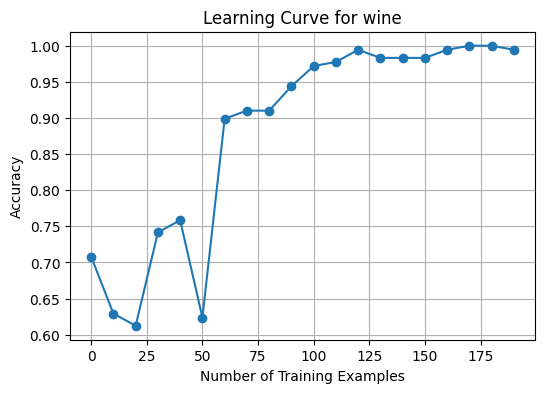

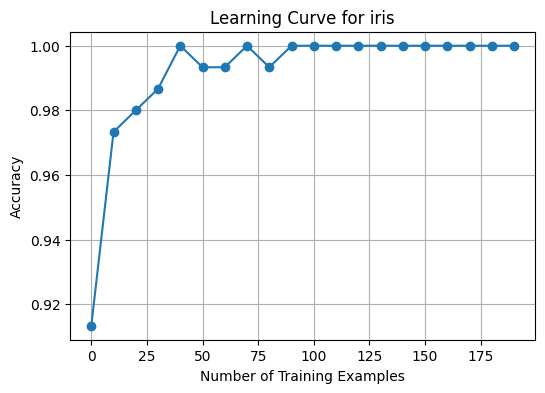

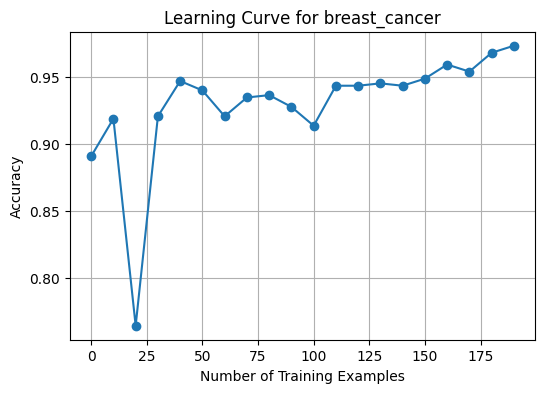

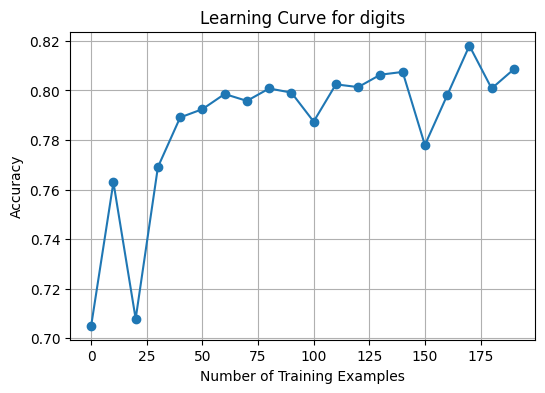

In [3]:
import matplotlib.pyplot as plt
for key, value in results.items():

    # Suppose `data` is your list of (num_examples, accuracy) tuples

    examples, accuracy = zip(*value['accuracy'])

    # Plot
    plt.figure(figsize=(6,4))
    plt.plot(examples, accuracy, marker='o', linestyle='-')
    plt.xlabel('Number of Training Examples')
    plt.ylabel('Accuracy')
    plt.title(f'Learning Curve for {key}')
    plt.grid(True)
    plt.show()